# How can we optimize patient wait times in Hospitals?

### Our Goal

Our goal is to analyze and predict Emergency Room wait times using to identify the key factors driving delays. By understanding which variables most significantly impact wait times such as urgency level, time of day, staffing ratios, and facility capacity hospitals can implement targeted interventions to reduce patient wait times and improve overall patient satisfaction. This analysis provides actionable insights that hospitals can use to optimize resource allocation, adjust staffing schedules, and streamline ER processes.


In [211]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder

## Step 1: Data Loading

In [212]:
df = pd.read_csv('ER_Wait_Time_Dataset.csv') # load the dataset
df.head()

,Visit ID,Patient ID,Hospital ID,Hospital Name,Region,Visit Date,Day of Week,Season,Time of Day,Urgency Level,Nurse-to-Patient Ratio,Specialist Availability,Facility Size (Beds),Time to Registration (min),Time to Triage (min),Time to Medical Professional (min),Total Wait Time (min),Patient Outcome,Patient Satisfaction
0,HOSP-1-20240210-0001,PAT-00001,HOSP-1,Springfield General Hospital,Urban,2024-02-10 20:20:56,Saturday,Winter,Late Morning,Medium,4,3,92,17,22,66,105,Discharged,1
1,HOSP-3-20241128-0001,PAT-00002,HOSP-3,Northside Community Hospital,Rural,2024-11-28 02:07:47,Thursday,Fall,Evening,Medium,4,0,38,9,30,30,69,Discharged,3
2,HOSP-3-20240930-0002,PAT-00003,HOSP-3,Northside Community Hospital,Rural,2024-09-30 04:02:28,Monday,Fall,Evening,Low,5,1,38,38,40,125,203,Discharged,1
3,HOSP-2-20240227-0001,PAT-00004,HOSP-2,Riverside Medical Center,Urban,2024-02-27 00:31:13,Tuesday,Winter,Evening,High,4,5,94,8,16,64,88,Discharged,2
4,HOSP-1-20240306-0002,PAT-00005,HOSP-1,Springfield General Hospital,Urban,2024-03-06 16:52:26,Wednesday,Spring,Afternoon,Low,4,8,74,26,29,63,118,Discharged,1


In [213]:
print("Dataset shape:", df.shape) # display basic information
print(df.columns.tolist()) # display the column names
print(df.dtypes) # display the data types
print(df.describe()) # display the basic statistics

Dataset shape: (5000, 19)
['Visit ID', 'Patient ID', 'Hospital ID', 'Hospital Name', 'Region', 'Visit Date', 'Day of Week', 'Season', 'Time of Day', 'Urgency Level', 'Nurse-to-Patient Ratio', 'Specialist Availability', 'Facility Size (Beds)', 'Time to Registration (min)', 'Time to Triage (min)', 'Time to Medical Professional (min)', 'Total Wait Time (min)', 'Patient Outcome', 'Patient Satisfaction']
Visit ID                              object
Patient ID                            object
Hospital ID                           object
Hospital Name                         object
Region                                object
Visit Date                            object
Day of Week                           object
Season                                object
Time of Day                           object
Urgency Level                         object
Nurse-to-Patient Ratio                 int64
Specialist Availability                int64
Facility Size (Beds)                   int64
Time to Regi

In [214]:
# Check for missing values
print("Missing values:\n", df.isnull().sum())
print("\nTarget variable stats:")
print(df['Total Wait Time (min)'].describe())

Missing values:
 Visit ID                              0
Patient ID                            0
Hospital ID                           0
Hospital Name                         0
Region                                0
Visit Date                            0
Day of Week                           0
Season                                0
Time of Day                           0
Urgency Level                         0
Nurse-to-Patient Ratio                0
Specialist Availability               0
Facility Size (Beds)                  0
Time to Registration (min)            0
Time to Triage (min)                  0
Time to Medical Professional (min)    0
Total Wait Time (min)                 0
Patient Outcome                       0
Patient Satisfaction                  0
dtype: int64

Target variable stats:
count    5000.000000
mean       81.916600
std        68.084538
min         4.000000
25%        27.000000
50%        60.000000
75%       122.000000
max       442.000000
Name: Total Wait T

## Step 2: Exploratory Data Analysis

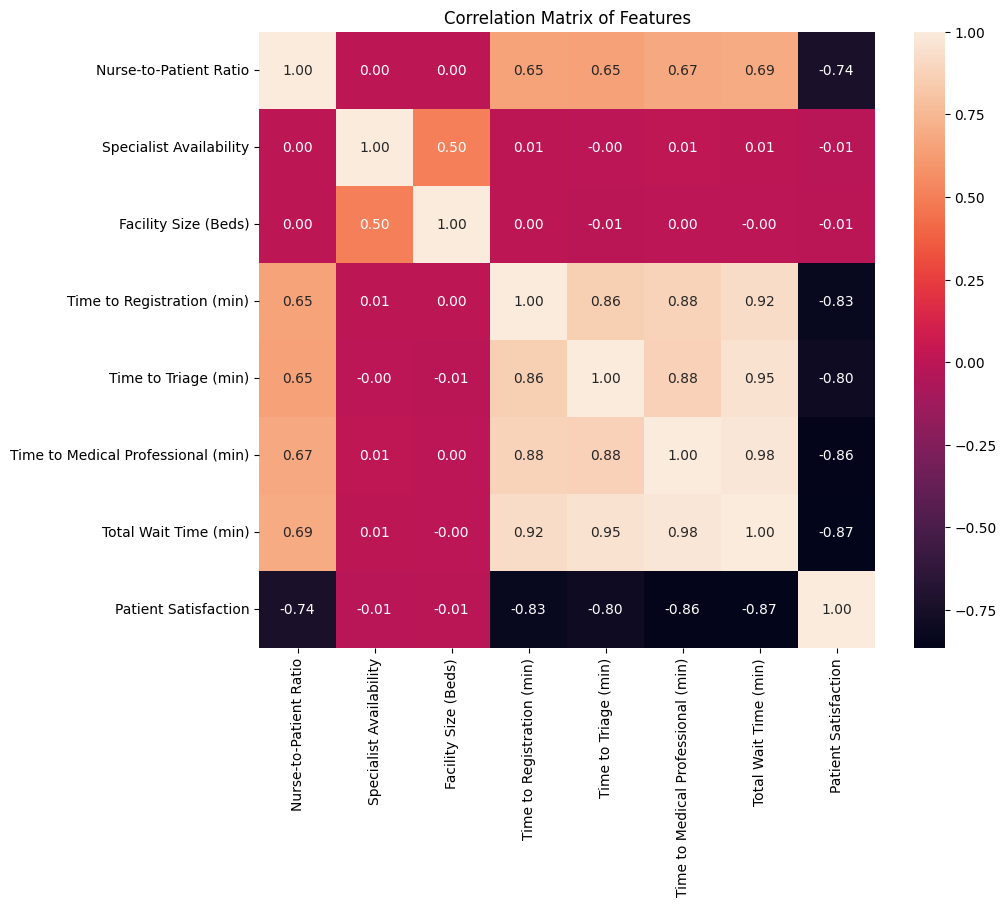

In [215]:
correlation_matrix = df.corr(numeric_only = True)
correlation_matrix

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix,cbar=True,annot=True,
                 square=True,fmt='.2f',
                 annot_kws={'size': 10})
plt.title('Correlation Matrix of Features')
plt.show() 

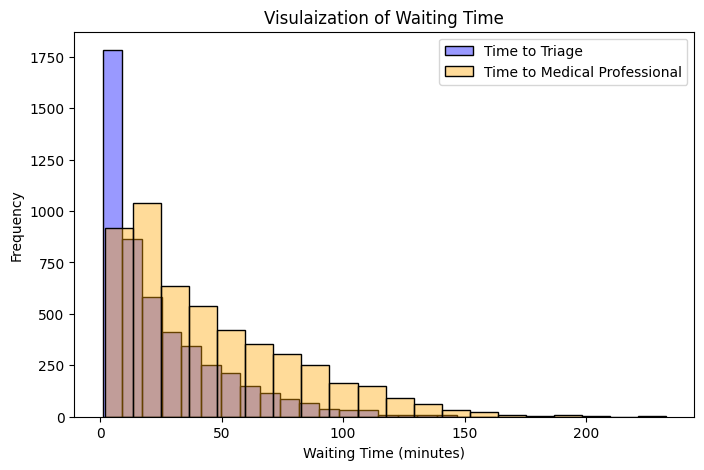

In [216]:
plt.figure(figsize=(8,5))

# sns.histplot(df['Time to Registration (min)'], color='blue', alpha=0.5, label='Registration Time', bins=20)
sns.histplot(df['Time to Triage (min)'], color='blue', alpha=0.4, label='Time to Triage', bins=20)
sns.histplot(df['Time to Medical Professional (min)'], color='orange', alpha=0.4, label='Time to Medical Professional', bins=20)

plt.xlabel('Waiting Time (minutes)')
plt.ylabel('Frequency')
plt.title('Visulaization of Waiting Time')
plt.legend()
plt.show()

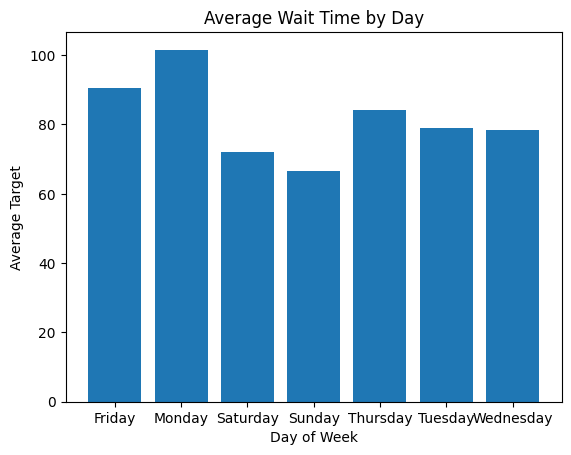

In [217]:
avg_day = df.groupby('Day of Week')['Total Wait Time (min)'].mean().reset_index()

plt.bar(avg_day['Day of Week'], avg_day['Total Wait Time (min)'])
plt.xlabel('Day of Week')
plt.ylabel('Average Target')
plt.title('Average Wait Time by Day')
plt.show()

Text(0.5, 1.0, 'Nurse to Patient Ratio vs. Average Wait Time')

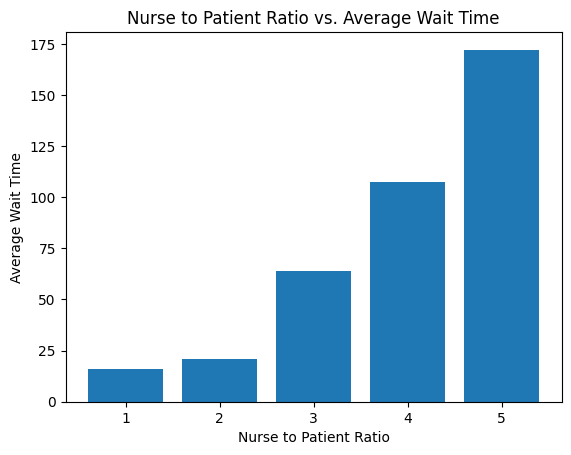

In [218]:
avg_df = df.groupby('Nurse-to-Patient Ratio')['Total Wait Time (min)'].mean().reset_index()
plt.bar(avg_df['Nurse-to-Patient Ratio'], avg_df['Total Wait Time (min)'])

plt.xlabel('Nurse to Patient Ratio')
plt.ylabel('Average Wait Time')
plt.title('Nurse to Patient Ratio vs. Average Wait Time')

# Step 3: Data Preprocessing

Feature Encoding

In [219]:
# Encode ordinal features
urgency_map = {'Low': 1, 'Medium': 2, 'High': 3, 'Critical': 4}
df['Urgency Encoded'] = df['Urgency Level'].map(urgency_map)

time_map = {'Morning': 1, 'Late Morning': 2, 'Afternoon': 3, 'Evening': 4, 'Night': 5}
df['Time Encoded'] = df['Time of Day'].map(time_map)

season_map = {'Spring': 1, 'Summer': 2, 'Fall': 3, 'Winter': 4}
df['Season Encoded'] = df['Season'].map(season_map)

# Encode categorical features
df['Region Encoded'] = LabelEncoder().fit_transform(df['Region'])
df['Is Weekend'] = df['Day of Week'].isin(['Saturday', 'Sunday']).astype(int)

# Select features for the model
features = [
    'Urgency Encoded',
    'Nurse-to-Patient Ratio',
    'Specialist Availability',
    'Facility Size (Beds)',
    'Time Encoded',
    'Season Encoded',
    'Region Encoded',
    'Is Weekend',
]

# Drop rows where any encoding produced NaN
# we do this to ensure that the model is not trained on any missing values
df_clean = df[features + ['Total Wait Time (min)']].dropna()
print(f"Rows after dropping NaN: {len(df_clean)} (dropped {len(df) - len(df_clean)})")

X = df_clean[features]
y = df_clean['Total Wait Time (min)']

print("Features shape:", X.shape)
print(X.head())

Rows after dropping NaN: 4527 (dropped 473)
Features shape: (4527, 8)
   Urgency Encoded  Nurse-to-Patient Ratio  Specialist Availability  \
0                2                       4                        3   
1                2                       4                        0   
2                1                       5                        1   
3                3                       4                        5   
4                1                       4                        8   

   Facility Size (Beds)  Time Encoded  Season Encoded  Region Encoded  \
0                    92           2.0               4               1   
1                    38           4.0               3               0   
2                    38           4.0               3               0   
3                    94           4.0               4               1   
4                    74           3.0               1               1   

   Is Weekend  
0           1  
1           0  
2           0  


In [220]:
df.groupby('Day of Week')['Total Wait Time (min)'].mean().sort_values()

Day of Week
Sunday        66.555862
Saturday      72.135521
Wednesday     78.295252
Tuesday       79.076923
Thursday      84.229462
Friday        90.391241
Monday       101.578125
Name: Total Wait Time (min), dtype: float64

In [221]:
df.groupby('Hospital Name')['Total Wait Time (min)'].mean().sort_values(ascending=False)

Hospital Name
Springfield General Hospital    82.701207
St. Mary’s Regional Health      81.886432
Riverside Medical Center        81.806452
Northside Community Hospital    81.762763
Summit Health Center            81.427705
Name: Total Wait Time (min), dtype: float64

In [222]:
df.groupby('Time of Day')['Total Wait Time (min)'].mean().sort_values()

Time of Day
Early Morning    52.088795
Late Morning     68.100000
Night            74.573585
Afternoon        80.550599
Evening          99.708406
Name: Total Wait Time (min), dtype: float64

In [223]:
categorical_cols = [
    'Hospital Name',
    'Region',
    'Day of Week',
    'Season',
    'Time of Day',
    'Urgency Level',
    'Patient Outcome'
]

for col in categorical_cols:
    print(f"\n=== {col} ===")
    print(df.groupby(col)['Total Wait Time (min)'].mean().sort_values(ascending=False))


=== Hospital Name ===
Hospital Name
Springfield General Hospital    82.701207
St. Mary’s Regional Health      81.886432
Riverside Medical Center        81.806452
Northside Community Hospital    81.762763
Summit Health Center            81.427705
Name: Total Wait Time (min), dtype: float64

=== Region ===
Region
Urban    81.977711
Rural    81.824473
Name: Total Wait Time (min), dtype: float64

=== Day of Week ===
Day of Week
Monday       101.578125
Friday        90.391241
Thursday      84.229462
Tuesday       79.076923
Wednesday     78.295252
Saturday      72.135521
Sunday        66.555862
Name: Total Wait Time (min), dtype: float64

=== Season ===
Season
Winter    98.457870
Summer    89.686963
Spring    72.421353
Fall      66.428687
Name: Total Wait Time (min), dtype: float64

=== Time of Day ===
Time of Day
Evening          99.708406
Afternoon        80.550599
Night            74.573585
Late Morning     68.100000
Early Morning    52.088795
Name: Total Wait Time (min), dtype: float64


In [224]:
pivot = df.pivot_table(
    values='Total Wait Time (min)',
    index='Day of Week',
    columns='Time of Day',
    aggfunc='mean'
)

print(pivot)

Time of Day  Afternoon  Early Morning     Evening  Late Morning      Night
Day of Week                                                               
Friday       89.888350      59.666667  107.722892     75.346939  80.587302
Monday       97.856557      56.918919  127.138776     89.613445  94.302326
Saturday     73.834862      46.842105   86.056277     56.380531  67.695122
Sunday       62.188940      38.050847   79.869732     60.745763  64.271429
Thursday     81.963918      57.821918  107.048980     63.521739  73.569620
Tuesday      80.131004      51.232877   94.725806     65.165138  72.085366
Wednesday    76.036082      50.485294   95.857724     65.734694  67.117647


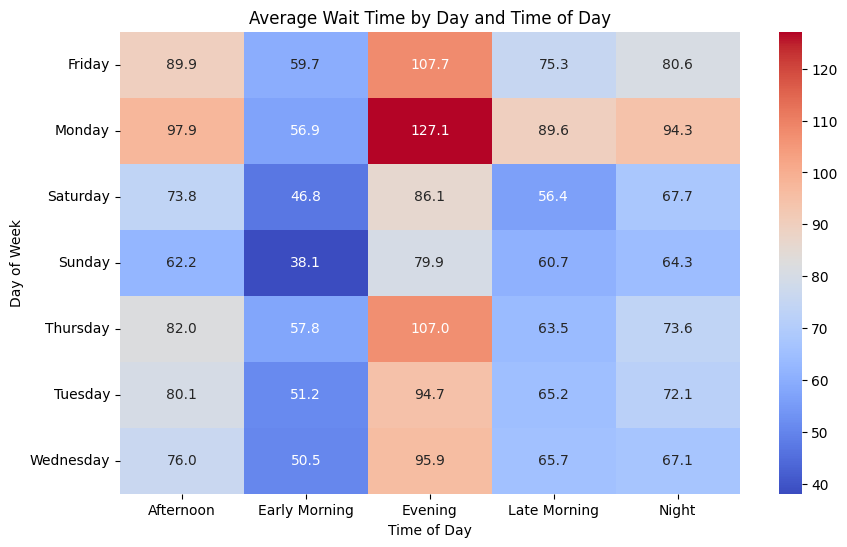

In [225]:
plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="coolwarm")

plt.title("Average Wait Time by Day and Time of Day")
plt.show()

In [226]:
df.groupby('Is Weekend')['Total Wait Time (min)'].mean()

Is Weekend
0    86.951035
1    69.298738
Name: Total Wait Time (min), dtype: float64

In [227]:
df.groupby('Urgency Level')['Total Wait Time (min)'].mean()

Urgency Level
Critical     18.351047
High         43.187149
Low         173.536825
Medium       93.695585
Name: Total Wait Time (min), dtype: float64

In [228]:
df.groupby(['Region', 'Time of Day'])['Total Wait Time (min)'].mean()

Region  Time of Day  
Rural   Afternoon         78.492512
        Early Morning     54.873016
        Evening          103.244275
        Late Morning      64.737179
        Night             75.063291
Urban   Afternoon         81.923418
        Early Morning     50.235915
        Evening           97.543925
        Late Morning      70.390830
        Night             74.177474
Name: Total Wait Time (min), dtype: float64

In [229]:
df.groupby(['Hospital Name', 'Day of Week', 'Time of Day'])['Total Wait Time (min)'] \
  .mean() \
  .sort_values(ascending=False) \
  .head(10)

Hospital Name                 Day of Week  Time of Day
Northside Community Hospital  Monday       Evening        154.133333
St. Mary’s Regional Health    Monday       Evening        126.937500
Riverside Medical Center      Monday       Evening        126.722222
Springfield General Hospital  Monday       Evening        123.630435
Northside Community Hospital  Friday       Evening        120.439024
St. Mary’s Regional Health    Friday       Evening        119.255814
Summit Health Center          Thursday     Evening        116.867925
Northside Community Hospital  Wednesday    Evening        114.645833
Riverside Medical Center      Thursday     Evening        112.681818
                              Friday       Evening        111.446809
Name: Total Wait Time (min), dtype: float64

In [234]:
avg_times = df[[
    'Time to Registration (min)', 
    'Time to Triage (min)', 
    'Time to Medical Professional (min)'
]].mean()

print("\nAverage Time per Stage (minutes):")
print(avg_times)


Average Time per Stage (minutes):
Time to Registration (min)            11.7042
Time to Triage (min)                  24.8270
Time to Medical Professional (min)    45.3854
dtype: float64


# Step 4: Model Building

# Linear Regression

In [230]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f} minutes")
print(f"RMSE: {rmse:.2f} minutes")
print(f"R² Score: {r2:.4f}")

MAE: 24.56 minutes
RMSE: 35.23 minutes
R² Score: 0.7521


In [231]:
# Feature coefficients — which factors drive wait time?
coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': model.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print("Feature Coefficients (impact on Total Wait Time):")
print(coef_df.to_string(index=False))

Feature Coefficients (impact on Total Wait Time):
                Feature  Coefficient
        Urgency Encoded   -56.803161
             Is Weekend   -20.172454
           Time Encoded     8.535387
         Season Encoded     6.759872
 Nurse-to-Patient Ratio    -3.592331
         Region Encoded     0.646547
Specialist Availability    -0.141549
   Facility Size (Beds)    -0.005053


## Random Forest

### How the Model Works
Random Forest predicts ER wait time by building many decision trees that learn different patterns in the data (like how urgency, time, and staffing interact) and then averaging their predictions to produce a more accurate and robust estimate.

In [232]:
# Initialize model
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

# Train
rf_model.fit(X_train, y_train)

# Predict
y_pred_rf = rf_model.predict(X_test)

In [233]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Performance:")
print(f"MAE: {mae_rf:.2f} minutes")
print(f"RMSE: {rmse_rf:.2f} minutes")
print(f"R² Score: {r2_rf:.4f}")

Random Forest Performance:
MAE: 15.05 minutes
RMSE: 24.27 minutes
R² Score: 0.8823


In [235]:
std_times = df[[
    'Time to Registration (min)', 
    'Time to Triage (min)', 
    'Time to Medical Professional (min)'
]].std()

print("\nStandard Deviation (variability):")
print(std_times)


Standard Deviation (variability):
Time to Registration (min)            10.437284
Time to Triage (min)                  24.807994
Time to Medical Professional (min)    35.619975
dtype: float64


In [236]:
peak_analysis = df.groupby('Time of Day')[[
    'Time to Registration (min)', 
    'Time to Triage (min)', 
    'Time to Medical Professional (min)'
]].mean()

print("\nAverage Stage Times by Time of Day:")
print(peak_analysis)


Average Stage Times by Time of Day:
               Time to Registration (min)  Time to Triage (min)  \
Time of Day                                                       
Afternoon                       11.615846             24.346871   
Early Morning                    7.103594             15.754757   
Evening                         14.325217             30.135652   
Late Morning                     9.758442             20.851948   
Night                           10.356604             22.781132   

               Time to Medical Professional (min)  
Time of Day                                        
Afternoon                               44.587883  
Early Morning                           29.230444  
Evening                                 55.247536  
Late Morning                            37.489610  
Night                                   41.435849  


# Gradient Boosting

In [239]:
from sklearn.ensemble import GradientBoostingRegressor

# Initialize model
gb_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

# Train
gb_model.fit(X_train, y_train)

# Predict
y_pred_gb = gb_model.predict(X_test)

In [240]:
mae_gb = mean_absolute_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
r2_gb = r2_score(y_test, y_pred_gb)

print("Gradient Boosting Performance:")
print(f"MAE: {mae_gb:.2f} minutes")
print(f"RMSE: {rmse_gb:.2f} minutes")
print(f"R² Score: {r2_gb:.4f}")

Gradient Boosting Performance:
MAE: 14.05 minutes
RMSE: 22.22 minutes
R² Score: 0.9014


# Neural Networks

In [237]:
import torch.nn as nn

class WaitTimeNet(nn.Module):
    def __init__(self, input_size, hidden1_size=64, hidden2_size=32):
        super(WaitTimeNet, self).__init__()

        # Fully connected layers
        self.fc1 = nn.Linear(input_size, hidden1_size)
        self.fc2 = nn.Linear(hidden1_size, hidden2_size)
        self.fc3 = nn.Linear(hidden2_size, 1)  # single output for regression

        # Activations
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)   # output shape: (batch_size, 1)
        return x


In [238]:
X = df.drop(columns=[
    'Hospital Name', 'Visit Date', 'Total Wait Time (min)', 
    'Patient Outcome', 'Process Sum', 'Reg %', 'Triage %', 'Doctor %',
    'Time to Registration (min)', 'Time to Triage (min)', 'Time to Medical Professional (min)'
])

categorical_cols = ['Region', 'Day of Week', 'Season', 'Time of Day', 'Urgency Level']
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

y = df['Total Wait Time (min)'].astype(float)
X = X.astype(float)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train = X_train.fillna(X_train.mean())
X_test  = X_test.fillna(X_train.mean()) 

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_t  = torch.tensor(X_test_scaled, dtype=torch.float32)

y_mean = y_train.mean()
y_std  = y_train.std()

y_train_scaled = (y_train - y_mean) / y_std
y_test_scaled  = (y_test - y_mean) / y_std

y_train_t = torch.tensor(y_train_scaled.values, dtype=torch.float32).unsqueeze(1)
y_test_t  = torch.tensor(y_test_scaled.values, dtype=torch.float32).unsqueeze(1)

KeyError: "['Process Sum', 'Reg %', 'Triage %', 'Doctor %'] not found in axis"

In [ ]:
batch_size = 32

train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
input_size = X_train_t.shape[1]

model = WaitTimeNet(input_size).to(device)

criterion = nn.MSELoss()              # regression loss
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [ ]:
num_epochs = 50
train_losses = []

for epoch in range(num_epochs):
    model.train()
    total_loss = 0.0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        preds = model(xb)                 # shape: (batch_size, 1)
        loss = criterion(preds, yb)       # regression
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * xb.size(0)

    train_loss = total_loss / len(train_loader.dataset)
    train_losses.append(train_loss)

    rmse = train_loss ** 0.5

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{num_epochs}: train_loss={train_loss:.4f}, train_rmse={rmse:.2f}")

Epoch 10/50: train_loss=0.0445, train_rmse=0.21
Epoch 20/50: train_loss=0.0396, train_rmse=0.20
Epoch 30/50: train_loss=0.0368, train_rmse=0.19
Epoch 40/50: train_loss=0.0371, train_rmse=0.19
Epoch 50/50: train_loss=0.0337, train_rmse=0.18


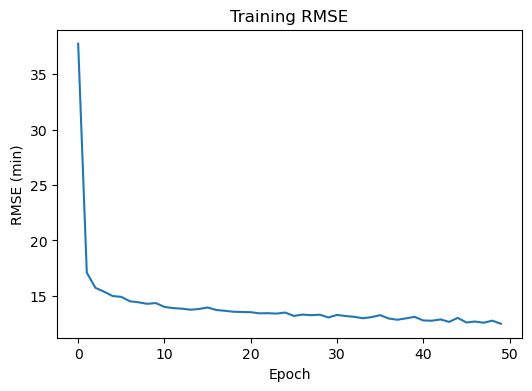

In [ ]:
train_rmse = [loss ** 0.5 * y_std for loss in train_losses]
plt.figure(figsize=(6,4))
plt.plot(train_rmse)
plt.xlabel('Epoch')
plt.ylabel('RMSE (min)')
plt.title('Training RMSE')
plt.show()

In [ ]:
model.eval()
with torch.no_grad():
    preds = model(X_test_t.to(device))
    preds_real = preds * y_std + y_mean
    y_real = y_test_t * y_std + y_mean
    val_rmse = torch.sqrt(torch.mean((preds_real - y_real.to(device))**2))
print(f"Validation RMSE: {val_rmse:.2f} min")

Validation RMSE: 16.12 min


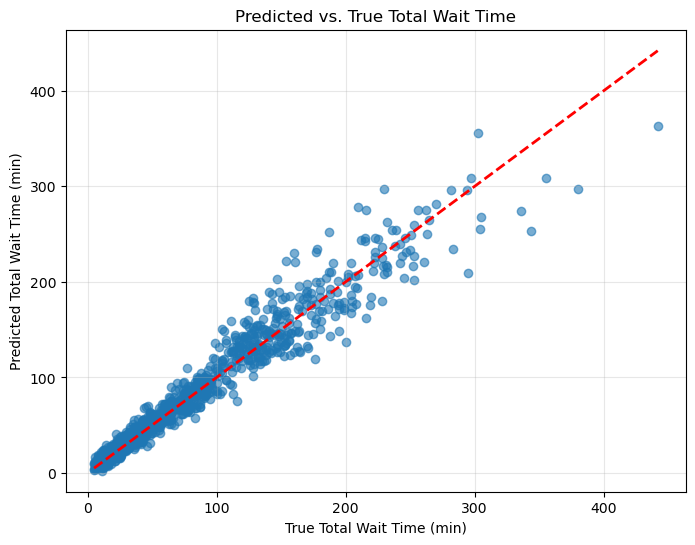

In [ ]:
# Get predictions (in original units)
model.eval()
with torch.no_grad():
    preds_scaled = model(X_test_t.to(device))
    preds = preds_scaled * y_std + y_mean  # unscale
    y_true = y_test_t * y_std + y_mean

plt.figure(figsize=(8,6))
plt.scatter(y_true.cpu(), preds.cpu(), alpha=0.6)
plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2)
plt.xlabel("True Total Wait Time (min)")
plt.ylabel("Predicted Total Wait Time (min)")
plt.title("Predicted vs. True Total Wait Time")
plt.grid(True, alpha=0.3)
plt.show()

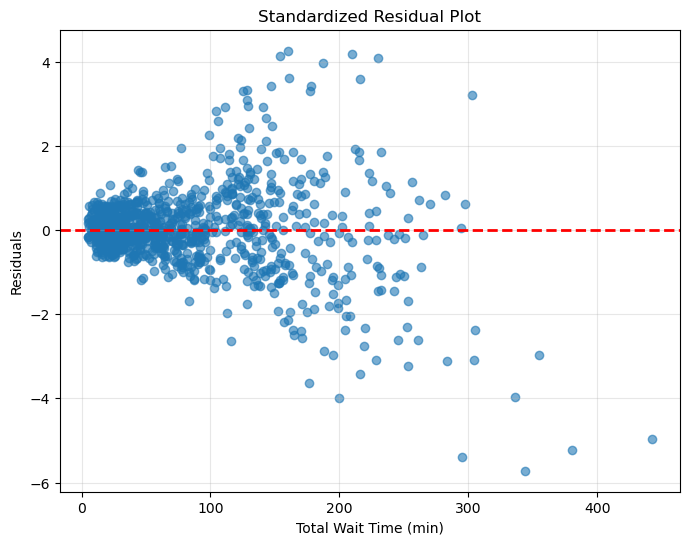

In [ ]:
residuals = (preds - y_true).cpu()
standardized = (residuals - residuals.mean())/residuals.std()
plt.figure(figsize=(8,6))
plt.scatter(y_true.cpu(), standardized, alpha=0.6)
plt.axhline(0, color='r', linestyle='--', lw=2)
plt.xlabel("Total Wait Time (min)")
plt.ylabel("Residuals")
plt.title("Standardized Residual Plot")
plt.grid(True, alpha=0.3)
plt.show()